In [4]:
pip install rasterio

   ---------------------------------------- 0.0/30.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/30.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.7 MB 2.7 MB/s eta 0:00:12
   - -------------------------------------- 1.3/30.7 MB 2.5 MB/s eta 0:00:12
   -- ------------------------------------- 1.6/30.7 MB 2.6 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/30.7 MB 2.3 MB/s eta 0:00:13
   --- ------------------------------------ 2.6/30.7 MB 2.4 MB/s eta 0:00:12
   --- ------------------------------------ 2.9/30.7 MB 2.1 MB/s eta 0:00:14
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ---- ----------------------------------- 3.4/30.7 MB 2.3 MB/s eta 0:00:13
   ----- ---------------------------------- 3.9/30.7 MB 1.8 MB/s eta 0:00:15
   ----- -----------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import openeo
import pandas as pd

# ==============================================================================
# 1. BACA KEDUA FILE ZIP (SAWAH & NON-SAWAH) DAN BERI LABEL OTOMATIS
# ==============================================================================
# Sesuaikan nama file zip non-sawah milikmu di baris kedua
gdf_sawah = gpd.read_file("Sawah-baron.zip").to_crs("EPSG:4326")
gdf_nonsawah = gpd.read_file("nonsawah-baron.zip").to_crs("EPSG:4326")

# Beri kolom label secara otomatis
gdf_sawah["label_teks"] = "Sawah"
gdf_sawah["label"] = 1

gdf_nonsawah["label_teks"] = "Non-Sawah"
gdf_nonsawah["label"] = 0

# Gabungkan keduanya menjadi 1 GeoDataFrame (50 + 50 = 100 sampel)
gdf_gabungan = gpd.GeoDataFrame(
    pd.concat([gdf_sawah, gdf_nonsawah], ignore_index=True), crs="EPSG:4326"
)

print(f"Jumlah sampel Sawah     : {len(gdf_sawah)}")
print(f"Jumlah sampel Non-Sawah : {len(gdf_nonsawah)}")
print(f"Total sampel gabungan   : {len(gdf_gabungan)}")

# ==============================================================================
# 2. AMBIL BATAS KOORDINAT GABUNGAN (BOUNDING BOX) UNTUK OPENEO
# ==============================================================================
minx, miny, maxx, maxy = gdf_gabungan.total_bounds
buffer_deg = 0.005  # Tambahan margin ~500 meter agar titik di tepi tetap masuk

bbox = {
    "west": float(minx - buffer_deg),
    "south": float(miny - buffer_deg),
    "east": float(maxx + buffer_deg),
    "north": float(maxy + buffer_deg),
}
print("Bounding Box Gabungan:", bbox)

# ==============================================================================
# 3. KONEKSI KE OPENEO & UNDUH SENTINEL-2A FORMAT GEOTIFF (.tif)
# ==============================================================================
conn = openeo.connect("openeo.dataspace.copernicus.eu")
conn.authenticate_oidc()

datacube = conn.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=bbox,
    temporal_extent=["2026-05-01", "2026-09-30"],  # Rentang waktu minim awan
    bands=[
        "B02",
        "B03",
        "B04",
        "B08",
        "B11",
    ],  # Blue, Green, Red, NIR, SWIR
    max_cloud_cover=10,
)

# Ambil median waktu agar bebas tutupan awan
composite_s2 = datacube.median_time()

# Unduh menjadi file GeoTIFF (.tif)
nama_tif = "sentinel2_sawah_nonsawah.tif"
print("Mengunduh citra Sentinel-2A (.tif)...")
composite_s2.download(nama_tif, format="GTiff")
print(f"Berhasil diunduh: {nama_tif}")

Jumlah sampel Sawah     : 51
Jumlah sampel Non-Sawah : 51
Total sampel gabungan   : 102
Bounding Box Gabungan: {'west': 112.0286883, 'south': -7.5874895, 'east': 112.0537555, 'north': -7.5647792}
Authenticated using refresh token.
Mengunduh citra Sentinel-2A (.tif)...
Berhasil diunduh: sentinel2_sawah_nonsawah.tif


In [5]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Buka file .tif Sentinel-2A dan samakan proyeksi koordinat (CRS)
with rasterio.open("sentinel2_sawah_nonsawah.tif") as src:
  gdf_projected = gdf_gabungan.to_crs(src.crs)

  # Ambil titik tengah (centroid) dari tiap sampel (mendukung Point maupun Polygon)
  koordinat_sampel = [
      (geom.centroid.x, geom.centroid.y) for geom in gdf_projected.geometry
  ]

  # Ekstrak nilai piksel dari kelima band Sentinel-2A
  nilai_band = list(src.sample(koordinat_sampel))

# 2. Buat tabel DataFrame Fitur
df_dataset = pd.DataFrame(nilai_band, columns=["B02", "B03", "B04", "B08", "B11"])

# 3. Tambahkan fitur indeks vegetasi (NDVI) & indeks air (NDWI)
df_dataset["NDVI"] = (df_dataset["B08"] - df_dataset["B04"]) / (
    df_dataset["B08"] + df_dataset["B04"] + 1e-6
)
df_dataset["NDWI"] = (df_dataset["B03"] - df_dataset["B08"]) / (
    df_dataset["B03"] + df_dataset["B08"] + 1e-6
)

# 4. Masukkan Koordinat & Label Kelas (Sawah = 1, Non-Sawah = 0)
df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y
df_dataset["Kelas"] = gdf_gabungan["label_teks"]
df_dataset["Target"] = gdf_gabungan["label"]

# Simpan ke CSV (bisa dipakai juga kalau mau diolah di KNIME)
df_dataset.to_csv("dataset_100sampel_sawah_nonsawah.csv", index=False)
print("Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'")
display(df_dataset.head())

# ==============================================================================
# 5. PROSES KLASIFIKASI 2 KELAS (SAWAH VS NON-SAWAH)
# ==============================================================================
fitur_kolom = ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# Split 80% Training (40 Sawah + 40 Non-Sawah) & 20% Testing (10 Sawah + 10 Non-Sawah)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Evaluasi pada data uji
y_pred = model_rf.predict(X_test)
print(
    "\n=== HASIL EVALUASI KLASIFIKASI 2 KELAS ==="
)
print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Dataset berhasil disimpan ke 'dataset_100sampel_sawah_nonsawah.csv'


C:\Users\Asus\AppData\Local\Temp\ipykernel_7104\276632000.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Longitude"] = gdf_gabungan.geometry.centroid.x
C:\Users\Asus\AppData\Local\Temp\ipykernel_7104\276632000.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df_dataset["Latitude"] = gdf_gabungan.geometry.centroid.y


,B02,B03,B04,B08,B11,NDVI,NDWI,Longitude,Latitude,Kelas,Target
0,517,663,470,2654,1631,0.699104,-0.600241,112.034155,-7.576800,Sawah,1
1,514,685,507,2969,1806,0.708285,-0.625068,112.037241,-7.576929,Sawah,1
2,520,669,452,3169,1601,0.750345,-0.651381,112.035995,-7.577839,Sawah,1
3,546,747,458,2864,1698,0.724262,-0.586264,112.039530,-7.574546,Sawah,1
4,705,949,813,2847,1861,0.555738,-0.500000,112.036919,-7.574629,Sawah,1



=== HASIL EVALUASI KLASIFIKASI 2 KELAS ===
Akurasi Testing : 95.24%

Confusion Matrix:
 [[10  1]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      0.91      0.95        11
       Sawah       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



In [8]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

# 1. Muat dataset dari CSV
df_dataset = pd.read_csv("dataset_100sampel_sawah_nonsawah.csv")

# 2. Siapkan fitur dan target
fitur_kolom = [c for c in ["B02", "B03", "B04", "B08", "B11", "NDVI", "NDWI"] if c in df_dataset.columns]
X = df_dataset[fitur_kolom]
y = df_dataset["Kelas"]

# 3. Split 80% Training & 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Latih model Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

print(f"Akurasi Testing : {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Akurasi Testing : 95.24%

Confusion Matrix:
 [[10  1]
 [ 0 10]]

Classification Report:
               precision    recall  f1-score   support

   Non-Sawah       1.00      0.91      0.95        11
       Sawah       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



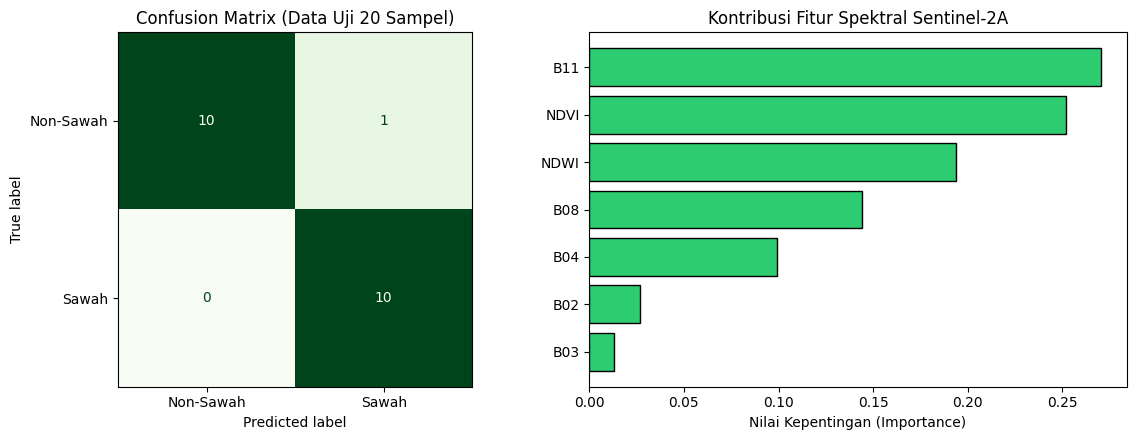

In [9]:
# ==============================================================================
# A. VISUALISASI CONFUSION MATRIX & FEATURE IMPORTANCE
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1. Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Greens", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion Matrix (Data Uji 20 Sampel)")

# 2. Plot Tingkat Kepentingan Fitur (Band & Indeks Spektral)
importances = model_rf.feature_importances_
indices = np.argsort(importances)
axes[1].barh(
    range(len(indices)),
    importances[indices],
    color="#2ecc71",
    edgecolor="black",
)
axes[1].set_yticks(range(len(indices)))
axes[1].set_yticklabels([fitur_kolom[i] for i in indices])
axes[1].set_xlabel("Nilai Kepentingan (Importance)")
axes[1].set_title("Kontribusi Fitur Spektral Sentinel-2A")

plt.tight_layout()
plt.show()

In [11]:
print(X_train.shape)

(81, 7)
